In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import operator
import random

# Module 4 Assignment: Diffusion Models

Below, you are going to be given a series of functions which simulate different diffusion models. To simulate a model, we need to select seed nodes, select the model, configure the model, and run the model through iterations. All of the steps are implemented for you except for configuring the model, which will be your task for each model in this assignment. Don't worry! It's very simple. The tutorial contains an example of a model being configured if you'd like to see an example.

Each simulation function in this assignment will output a list of numbers, where each number represents the number of nodes infected at that iteration(the first number is how many nodes were infected after 1 iteration and so on).
  

If you are stuck on how to configure these models, refer to the oficial documentation or the tutorial we've provided for this assignment.

In [2]:
G=nx.read_edgelist("assets/german.txt", delimiter=' ')

# Part 1: Threshold Model

Remember that the threshold model gives each node a threshold for the percentage of its neighbors that must be infected before being infected. If the threshold is exceeded, the node becomes infected.

# Task 1a: Simulation



In this part of the assignment, you will be configuring the [threshold model](https://ndlib.readthedocs.io/en/latest/reference/models/epidemics/Threshold.html).


This, and all future simulation functions have two options for determining seed nodes:
- Passing a function as input (```importance_measure```), which takes in G and outputs a dictionary with nodes as the keys and scores as the values. For example, ```importance_measure``` could output a dictionary with nodes as the keys and the degrees of the nodes as the values. Your function should use the top `n` nodes based on these scores as the seed nodes. In your function, we place the seed nodes based on this criteria in the list ```highest_nodes``` for you, which you can see below.

- If ```importance_measure``` is not passed, then your function should pick a random ```float(n)/len(G.nodes)``` fraction of nodes to be infected instead. 

**Hints**

There are two ways for `ModelConfig` to select seed nodes:

- To specify a list of initially infected nodes `infected_nodes` use:
    ```python
    config.add_model_initial_configuration("Infected", infected_nodes)
    ``` 
- To choose a random fraction of infected nodes, instead do:
    ```python
    config.add_model_parameter('fraction_infected', fraction)
    ```


In [3]:
task_id = '1a'


In [4]:
def task_1a_solution(G, importance_measure=None, iterate=50, n=1, threshold=0.25):
    ## This part is done for you, selecting the seed nodes. 
    if importance_measure:
        
        sorted_node = sorted(importance_measure(G).items(), key=operator.itemgetter(1))[::-1]
        highest_nodes = [n for n, _ in sorted_node[:n]]
        config = mc.Configuration()
        config.add_model_initial_configuration("Infected", highest_nodes)

    else: 
        config = mc.Configuration()
        config.add_model_parameter("fraction_infected", float(n)/len(G.nodes))

    # Model selection
    model = ep.ThresholdModel(G, seed = 42)
    
    

    for node in G.nodes:
        config.add_node_configuration("threshold", node, threshold)

    model.set_initial_status(config)
    iterations = model.iteration_bunch(iterate)
    return [it['node_count'][1] for it in iterations]

In [5]:
# Use this cell to explore your solution.

task_1a_solution(G)

[1,
 2,
 5,
 10,
 13,
 18,
 23,
 29,
 38,
 46,
 54,
 65,
 74,
 85,
 95,
 105,
 115,
 124,
 136,
 154,
 177,
 200,
 227,
 255,
 280,
 314,
 351,
 390,
 430,
 475,
 525,
 579,
 630,
 691,
 746,
 789,
 847,
 894,
 930,
 958,
 983,
 1008,
 1029,
 1048,
 1068,
 1086,
 1103,
 1118,
 1130,
 1139]

In [6]:
print(f"Task {task_id} - AG tests")



#hidden tests are within this cell

Task 1a - AG tests


# Task 1b: Analysis

Now, for the second part of the model, we'll have a task analyzing the results of the simulated diffusion model. In this module, you learned about several methods of choosing the initial nodes to be infected at the start of the simulation, known as the seed nodes. 

Below, we use 5 methods of picking seed nodes to decide the seed nodes of the model and simulate the diffusion model after selecting these seed nodes. Which method resulted in the least infected nodes after 50 iterations?

The function below should return a string with one of the following possible values:

[random, degree, closeness, betweenness, pagerank]

Below, we provide a brief summaries on what each method of seed node selection refers to:
- Random: Seed nodes are selected arbitrarily without considering network structure, leading to unpredictable influence spread.

- Degree: Nodes with the highest number of direct connections are chosen, assuming they can quickly spread influence to many others.

- Closeness: Nodes that have the shortest average distance to all other nodes are selected, optimizing fast information dissemination.

- Betweenness: Nodes that act as bridges between different parts of the network are prioritized, ensuring influence reaches diverse regions.

- PageRank: Nodes with high importance based on recursive link analysis are selected, favoring those connected to other influential nodes.


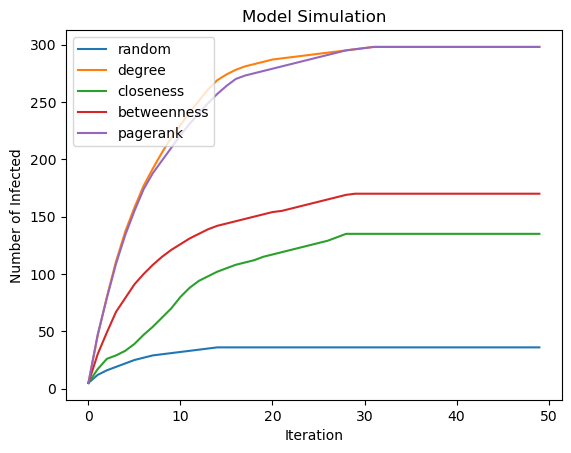

In [7]:
task_id = '1b'
I=50
N=5
T=0.3

node_count_random = task_1a_solution(G, n=N, iterate=I, threshold=T)
node_count_deg = task_1a_solution(G, nx.degree_centrality, n=N, iterate=I, threshold=T)
node_count_closeness = task_1a_solution(G, nx.closeness_centrality, n=N, iterate=I, threshold=T)
node_count_betweenness = task_1a_solution(G, nx.betweenness_centrality, n=N, iterate=I, threshold=T)
node_count_pagerank = task_1a_solution(G, nx.pagerank, n=N, iterate=I, threshold=T)

plt.title("Model Simulation")
plt.xlabel("Iteration")
plt.ylabel("Number of Infected")
plt.plot(node_count_random, label='random')
plt.plot(node_count_deg, label='degree')
plt.plot(node_count_closeness, label='closeness')
plt.plot(node_count_betweenness, label='betweenness')
plt.plot(node_count_pagerank, label='pagerank')
plt.legend()

In [8]:
def task_1b_solution():
    sol = "random"

    

    return sol

In [9]:
print(f"Task {task_id} - AG tests")


Task 1b - AG tests


# Part 2: Independent Cascade Model

Recall that the Independent Cascade Model is similar to the Threshold Model, except nodes do not have their own threshold. Instead, each edge has a probability of infecting the node it's directed to.




# Task 2a: Simulation

You will be selecting seed nodes the same way as you did in Task 1. However, configuring the model will be different, as you will be adding probability values to the edges instead of threshold values to nodes. Refer to the tutorial for a guide on how to accomplish this.


In [10]:
task_id = '2a'


In [11]:
def task_2a_solution(G, importance_measure=None, iterate=50, n=1, threshold=0.25):
    ## This part is done for you, selecting the seed nodes. 
    if importance_measure:
        
        sorted_node = sorted(importance_measure(G).items(), key=operator.itemgetter(1))[::-1]
        highest_nodes = [n for n, _ in sorted_node[:n]]
        config = mc.Configuration()
        config.add_model_initial_configuration("Infected", highest_nodes)

    else:

        config = mc.Configuration()
        config.add_model_parameter("fraction_infected", float(n)/len(G.nodes))
    
    # Model selection
    model = ep.IndependentCascadesModel(G, seed = 42)
    
    for edge in G.edges():
        config.add_edge_configuration('threshold', edge, threshold)


    model.set_initial_status(config)

    
    # This part is done for you, simulating the infection spreading over time. 
    iterations = model.iteration_bunch(iterate)
    return [it['node_count'][1] + it['node_count'][2] for it in iterations]

In [12]:
print(f"Task {task_id} - AG tests")

#hidden tests are within this cell

Task 2a - AG tests


# Task 2b: Analysis

Let's take a look at the graph here simulating the Independent Cascade Model using "degree" as the seed node selection.


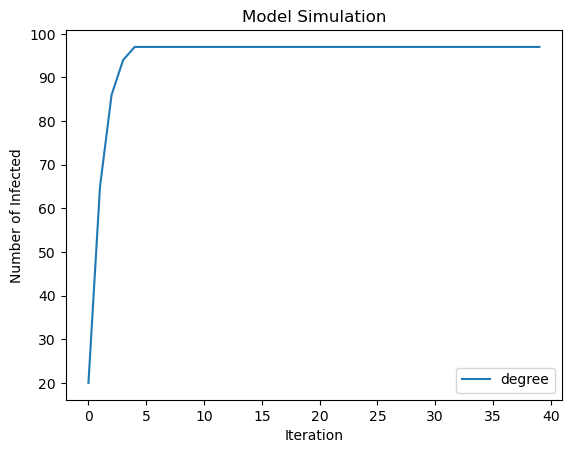

In [13]:
task_id = '2b'
I=40
N=20
T=0.3


node_count_deg = task_2a_solution(G, nx.degree_centrality, n=N, iterate=I, threshold=T)


plt.title("Model Simulation")
plt.xlabel("Iteration")
plt.ylabel("Number of Infected")

plt.plot(node_count_deg, label='degree')

plt.legend()

If you compare this graph to the graph from task 1b using degree, we can see that the number of infected nodes is quite a bit different from the threshold model! For this task, we're going to compute the difference between: 

`n_threshold_infected`: The number of nodes infected in the Linear Threshold Model using degree for the seeds

`n_IC_infected`: The number of nodes infected in the Independent Cascade Model (task 1b)using degree for the seeds


The function `task_2b_solution` should return the difference `n_threshold_infected` - `n_IC_infected` 


**Hints:**

- Recall what is returned by the task_1a and task_2a functions. You may want to refer back to the assignment introduction describing what is returned by these functions. When calling these functions, use the I, N, and T values defined above as values for the iterate, n, and threshold arguments, respectively. Use `nx.degree_centrality` as the argument for `importance_measure`.

- You can find the final element in a python list using reverse indexing. For example:
    ```Python
    last_element = my_list[-1]
    ```
    assigns the last element in ```my_list``` to ```last_element```

In [14]:
def task_2b_solution():
    threshold_res = task_1a_solution(
        G=G,
        importance_measure=nx.degree_centrality,
        n=N,
        iterate=I,
        threshold=T
    )

    ic_res = task_2a_solution(
        G=G,
        importance_measure=nx.degree_centrality,
        n=N,
        iterate=I,
        threshold=T
    )

    n_threshold_infected = threshold_res[-1]
    n_ic_infected = ic_res[-1]

    return int(n_threshold_infected - n_ic_infected)


In [15]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, int
), f"Task {task_id}: Your function should return an int. "



Task 2b - AG tests
Task 2b - your answer:
941


# Task 3: SIR Model

Remember, the SIR model is where infections pass along edges from infected nodes to others with a certain probability. Infected nodes can become "removed" or "permanently cured" with a different probability.

# Part 3a: Simulation

Simulating this model requires "infected" and "fraction_infected" as you've implemented in tasks 1 and 2. However, the model will require two separate properties, one being the probability of an infected node spreading its condition, and the other being the probability of a node becoming "permanently cured". These properties will be called 'beta' and 'gamma,' respectively. Values for these properties are passed in as arguments. Add these to the model configuration using ```add_model_parameter```.



**Hint**
The "Configuring a model" section of the tutorial shows you how to add extra parameters to the configuration with the add_model_parameter function. You can use this method to add the 'beta' and 'gamma' properties. 

In [16]:
task_id = '3a'


In [17]:
def task_3a_solution(G, importance_measure=None, iterate=100, n=1, beta=0.1, gamma=0.05):
    if importance_measure:
        # select seed nodes
        sorted_node = sorted(importance_measure(G).items(), key=operator.itemgetter(1))[::-1]
        highest_nodes = [n for n, _ in sorted_node[:n]]
        config = mc.Configuration()
        config.add_model_initial_configuration("Infected", highest_nodes)
        config.add_model_parameter("beta", beta)
        config.add_model_parameter("gamma", gamma)


    else:

        config = mc.Configuration()
        config.add_model_parameter("beta", beta)
        config.add_model_parameter("gamma", gamma)
        config.add_model_parameter("fraction_infected", float(n)/len(G.nodes))
    
    

    # Model selection
    model = ep.SIRModel(G, seed = 42)

    model.set_initial_status(config)
    

    # Simulation execution
    iterations = model.iteration_bunch(iterate)
    
    total_infected_nodes = [0] * iterate
    status = [0] * len(G.nodes)
    for item in iterations:
        for k, v in item['status'].items():
            if v == 1:
                status[int(k)] = 1
        total_infected_nodes[item['iteration']] = sum(status)
    
    return [it['node_count'][1] for it in iterations], total_infected_nodes

In [18]:
task_3a_solution(G)

([1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  2,
  2,
  2,
  2,
  3,
  3,
  2,
  2,
  2,
  2,
  3,
  3,
  4,
  4,
  4,
  7,
  8,
  11,
  12,
  15,
  17,
  15,
  17,
  18,
  18,
  18,
  20,
  20,
  23,
  25,
  26,
  27,
  27,
  26,
  25,
  25,
  26,
  24,
  25,
  22,
  23,
  25,
  25,
  24,
  23,
  23,
  22,
  21,
  22,
  21,
  21,
  21,
  18,
  17,
  18,
  19,
  16,
  15,
  15,
  15,
  15,
  14,
  13,
  13,
  12,
  12,
  12,
  14,
  14,
  12,
  10,
  10,
  9,
  8,
  7,
  7,
  7,
  7,
  7,
  7,
  8,
  8,
  7,
  6,
  6,
  5,
  4,
  4,
  3,
  3,
  3],
 [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  2,
  2,
  2,
  2,
  3,
  3,
  3,
  3,
  3,
  3,
  4,
  4,
  5,
  5,
  5,
  8,
  9,
  12,
  13,
  17,
  20,
  22,
  24,
  26,
  27,
  28,
  30,
  31,
  34,
  36,
  38,
  39,
  40,
  40,
  40,
  41,
  42,
  42,
  43,
  43,
  46,
  48,
  49,
  50,
  50,
  53,
  53,
  53,
  54,
  54,
  55,
  56,
  56,
  56,
  57,
  58,
  58,
  59,
  60,
  60,
  60,
  61,
  61,
  61,
  61,
  61,
  61,
  63,
  64,
  

In [19]:
print(f"Task {task_id} - AG tests")

#hidden tests are within this cell

Task 3a - AG tests


# Task 3b: Analysis

Since nodes can become "removed," the total number of nodes that have been infected at a given point can differ from the total number of nodes currently infected at that point. For example, if nodes 1, 2, and 3 are infected, and then at one point, node 3 becomes 'removed,' the total number of nodes that have been infected is 3, but the number of currently infected nodes is 2. 

As you may have noticed, our function above creates lists that count both the total number of nodes that have been infected and the number of nodes currently infected. We plot these lists in the  graphs below as a function of the iteration number for each of the seed selection methods. 

You will answer 2 questions based on these plots: 

- Which method of seed node selection resulted in the highest total number of infected nodes? (```mostTotal```)
- Which method of seed selection resulted in the highest number of infected nodes at a given point? (```mostAtPoint```)

Your answers should be put in the strings ```mostTotal``` and ```mostAtPoint```, respectively in the function in `task_4b answer()`. 

The strings should be one of the following answers:

["random", "degree", "closeness", "betweenness", "pagerank"]

For example, if PageRank generated the highest toatl number of infected nodes ```mostTotal``` should be "pagerank".

Text(0.5, 1.0, 'No. Nodes Infected Once')

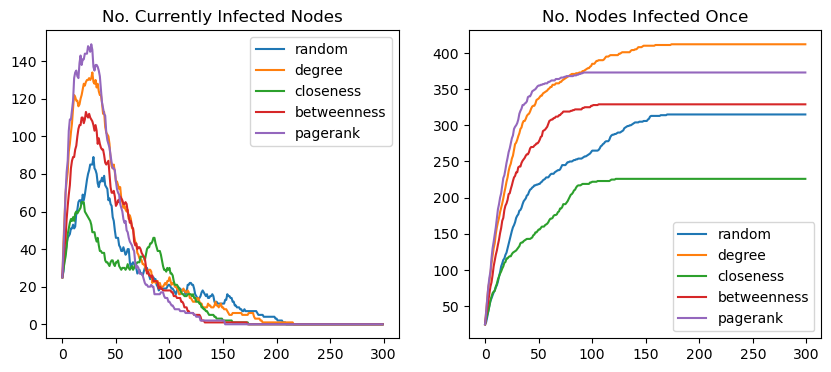

In [20]:
N=25
I=300
b = 0.1
g = 0.05

node_count_random, total_random = task_3a_solution(G, iterate=I, n=N, beta = b, gamma = g)
node_count_deg, total_deg = task_3a_solution(G, nx.degree_centrality, iterate=I, n=N, beta = b, gamma = g)
node_count_closeness, total_closeness = task_3a_solution(G, nx.closeness_centrality, iterate=I, n=N, beta = b, gamma = g)
node_count_betweenness, total_betweenness = task_3a_solution(G, nx.betweenness_centrality, iterate=I, n=N, beta = b, gamma = g)
node_count_pagerank, total_pagerank = task_3a_solution(G, nx.pagerank, iterate=I, n=N, beta = b, gamma = g)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(node_count_random, label='random')
axes[0].plot(node_count_deg, label='degree')
axes[0].plot(node_count_closeness, label='closeness')
axes[0].plot(node_count_betweenness, label='betweenness')
axes[0].plot(node_count_pagerank, label='pagerank')
axes[0].legend()
axes[0].set_title("No. Currently Infected Nodes")
axes[1].plot(total_random, label='random')
axes[1].plot(total_deg, label='degree')
axes[1].plot(total_closeness, label='closeness')
axes[1].plot(total_betweenness, label='betweenness')
axes[1].plot(total_pagerank, label='pagerank')
axes[1].legend()
axes[1].set_title("No. Nodes Infected Once")

In [21]:
def task_3b_solution():
    mostAtPoint = "pagerank"
    mostTotal = "degree"
    return mostAtPoint, mostTotal


In [22]:
print(f"Task {task_id} - AG tests")


Task 3a - AG tests


# Part 4: SIS Model

The SIS model is similar to the SIR model, but instead of becoming "permanently cured," nodes revert back to a susceptible state where they can become reinfected.

# Task 4a: Simulation

Configuring this model is the same as configuring the SIR model. However, instead of a `gamma` parameter determining if a node will become 'removed,' a `lambda` parameter determining whether a node will become 'susceptible' will be added.

Remember that you can use `add_model_parameter` to add the `lambda` parameter. 

In [23]:
task_id = '4a'




In [24]:
def task_4a_solution(G, importance_measure=None, iterate=100, n=1, beta=0.3, _lambda=0.2):
    if importance_measure:
        # select seed nodes
        sorted_node = sorted(importance_measure(G).items(), key=operator.itemgetter(1))[::-1]
        highest_nodes = [n for n, _ in sorted_node[:n]]
        config = mc.Configuration()
        config.add_model_initial_configuration("Infected", highest_nodes)
        config.add_model_parameter("beta", beta)
        config.add_model_parameter("lambda", _lambda)


    else:

        config = mc.Configuration()
        config.add_model_parameter("beta", beta)
        config.add_model_parameter("lambda", _lambda)
        config.add_model_parameter("fraction_infected", float(n)/len(G.nodes))
    
    
    
    # Model selection
    model = ep.SISModel(G, seed = 42)
    model.set_initial_status(config)


    # Simulation execution
    iterations = model.iteration_bunch(iterate)

    return iterations

In [25]:
print(f"Task {task_id} - AG tests")

stu_iters = task_4a_solution(G)

#hidden tests are within this cell

Task 4a - AG tests


# Task 4b: Analysis


A unique feature of this model in comparison to the others we've examined is that nodes can be infected multiple times. How many times was the node '0' infected?

For this question, you will need to examine the `iterations` object returned by task 4a and you will add code counting the number of times node '0' was infected and return that number as an integer. You may want to refer back to the tutorial describing the 'status' entry in an iteration.


In [26]:
task_id = '4b'



In [27]:
def task_4b_solution(G, importance_measure=None, iterate=100, n=1, beta=0.1, lambda_=0.05):
    iterations = task_4a_solution(G, importance_measure, iterate, n, beta, lambda_)

    node_infection_count = 0

    for it in iterations:
        status_changes = it.get("status", {})
        if 0 in status_changes and status_changes[0] == 1:
            node_infection_count += 1

    return node_infection_count


In [28]:
# Use this cell to explore your solution

task_4b_solution(G)

0

In [29]:

print(f"Task {task_id} - AG tests")

stu_ans = task_4b_solution(G)

assert isinstance(
    stu_ans, int
), f"Your function should return an int "




Task 4b - AG tests
